# Traffic Signal Optimization with Reinforcement Learning

This notebook implements a reinforcement learning agent to optimize traffic signal control and improve traffic throughput.

## Project Overview
- **Goal**: Minimize waiting time and maximize throughput at traffic intersections
- **Approach**: Train an RL agent to learn optimal signal timing policies
- **Environment**: Custom traffic simulation with configurable complexity

## Table of Contents
1. [Setup and Dependencies](#setup)
2. [Environment Definition](#environment)
3. [Baseline Controllers](#baseline)
4. [RL Agent Implementation](#agent)
   - 4.1 PPO Agent
   - 4.2 Custom Callback
   - **4.3 Q-Learning Agent** *(new)*
5. [Training](#training)
6. [Evaluation](#evaluation)
7. [Results and Analysis](#results)

## 1. Setup and Dependencies <a name="setup"></a>

In [3]:
# Install required packages (uncomment to install)
!pip install gymnasium stable-baselines3 numpy matplotlib pandas torch tensorboard seaborn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Dict, List, Tuple, Optional
from collections import deque
import gymnasium as gym
from gymnasium import spaces

# RL Libraries
from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

# Deep Learning
import torch
import torch.nn as nn

# Visualization
import seaborn as sns
sns.set_style('whitegrid')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("✓ All dependencies loaded successfully")

✓ All dependencies loaded successfully


## 2. Environment Definition <a name="environment"></a>

### 2.1 Traffic Simulation Core

In [5]:
class Vehicle:
    """Represents a single vehicle in the simulation."""
    
    def __init__(self, arrival_time: float, lane: int):
        self.arrival_time = arrival_time
        self.lane = lane  # 0: North, 1: East, 2: South, 3: West
        self.waiting_time = 0.0
        self.has_passed = False
        
    def update_waiting_time(self, dt: float):
        """Update waiting time if vehicle hasn't passed."""
        if not self.has_passed:
            self.waiting_time += dt

In [6]:
class TrafficGenerator:
    """Generates traffic according to specified patterns."""
    
    def __init__(self, 
                 arrival_rates: List[float],  # vehicles/second for each lane
                 pattern: str = 'uniform'):
        """
        Args:
            arrival_rates: List of 4 arrival rates for [North, East, South, West]
            pattern: 'uniform', 'rush_hour', or 'random'
        """
        self.base_rates = np.array(arrival_rates)
        self.pattern = pattern
        
    def generate_vehicles(self, dt: float, current_time: float) -> List[Vehicle]:
        """Generate new vehicles for this timestep."""
        vehicles = []
        rates = self._get_current_rates(current_time)
        
        for lane, rate in enumerate(rates):
            # Poisson process: probability of arrival in dt
            if np.random.random() < rate * dt:
                vehicles.append(Vehicle(current_time, lane))
                
        return vehicles
    
    def _get_current_rates(self, time: float) -> np.ndarray:
        """Modify arrival rates based on pattern."""
        if self.pattern == 'uniform':
            return self.base_rates
        elif self.pattern == 'rush_hour':
            # Simulate rush hour with sinusoidal pattern
            multiplier = 1.5 + 0.5 * np.sin(2 * np.pi * time / 3600)  # hourly cycle
            return self.base_rates * multiplier
        elif self.pattern == 'random':
            return self.base_rates * np.random.uniform(0.5, 1.5, size=4)
        return self.base_rates

### 2.2 Custom Traffic Signal Environment

In [7]:
class TrafficSignalEnv(gym.Env):
    """Custom Environment for Traffic Signal Control."""
    
    metadata = {'render_modes': ['human', 'rgb_array']}
    
    # Signal phases: (North-South Green, East-West Green, North-South Yellow, East-West Yellow)
    PHASES = {
        0: {'ns': 'green', 'ew': 'red'},      # North-South green
        1: {'ns': 'yellow', 'ew': 'red'},     # North-South yellow
        2: {'ns': 'red', 'ew': 'green'},      # East-West green
        3: {'ns': 'red', 'ew': 'yellow'},     # East-West yellow
    }
    
    def __init__(self, 
                 arrival_rates: List[float] = [0.2, 0.2, 0.2, 0.2],
                 episode_length: int = 3600,  # seconds
                 dt: float = 1.0,  # simulation timestep
                 min_green_time: int = 10,
                 yellow_time: int = 3,
                 max_queue_length: int = 50):
        """
        Initialize traffic signal environment.
        
        Args:
            arrival_rates: Vehicle arrival rates for each lane [N, E, S, W]
            episode_length: Length of episode in seconds
            dt: Simulation timestep in seconds
            min_green_time: Minimum green light duration
            yellow_time: Yellow light duration
            max_queue_length: Maximum vehicles in queue per lane
        """
        super().__init__()
        
        # Environment parameters
        self.arrival_rates = arrival_rates
        self.episode_length = episode_length
        self.dt = dt
        self.min_green_time = min_green_time
        self.yellow_time = yellow_time
        self.max_queue_length = max_queue_length
        
        # State space: [queue_lengths (4), waiting_times (4), current_phase (1), phase_time (1)]
        # Total: 10 dimensions
        self.observation_space = spaces.Box(
            low=0, 
            high=np.array([max_queue_length] * 4 + [1000] * 4 + [3, 120]),
            dtype=np.float32
        )
        
        # Action space: 0 = maintain current phase, 1 = switch to next phase
        self.action_space = spaces.Discrete(2)
        
        # Initialize traffic generator
        self.traffic_gen = TrafficGenerator(arrival_rates)
        
        # Reset environment
        self.reset()
        
    def reset(self, seed=None, options=None):
        """Reset the environment to initial state."""
        super().reset(seed=seed)
        
        # Reset time and phase
        self.current_time = 0
        self.current_phase = 0
        self.phase_time = 0
        
        # Reset queues (one per lane: N, E, S, W)
        self.queues = [deque() for _ in range(4)]
        
        # Statistics
        self.total_waiting_time = 0
        self.total_vehicles_passed = 0
        self.total_vehicles_arrived = 0
        
        # History for logging
        self.history = {
            'queue_lengths': [],
            'waiting_times': [],
            'throughput': [],
            'phases': []
        }
        
        return self._get_observation(), {}
    
    def step(self, action: int):
        """Execute one step in the environment."""
        
        # 1. Generate new vehicles
        new_vehicles = self.traffic_gen.generate_vehicles(self.dt, self.current_time)
        for vehicle in new_vehicles:
            if len(self.queues[vehicle.lane]) < self.max_queue_length:
                self.queues[vehicle.lane].append(vehicle)
                self.total_vehicles_arrived += 1
        
        # 2. Update phase based on action
        old_phase = self.current_phase
        if action == 1 and self.phase_time >= self.min_green_time:
            # Switch to next phase
            self.current_phase = (self.current_phase + 1) % 4
            self.phase_time = 0
        else:
            self.phase_time += self.dt
        
        # 3. Process vehicles based on current signal phase
        vehicles_passed = self._process_vehicles()
        
        # 4. Update waiting times for all queued vehicles
        total_waiting = 0
        for queue in self.queues:
            for vehicle in queue:
                vehicle.update_waiting_time(self.dt)
                total_waiting += vehicle.waiting_time
        
        # 5. Calculate reward
        reward = self._calculate_reward(vehicles_passed, total_waiting)
        
        # 6. Update statistics
        self.total_vehicles_passed += vehicles_passed
        self.total_waiting_time += total_waiting
        
        # 7. Log history
        self._log_state()
        
        # 8. Advance time
        self.current_time += self.dt
        
        # 9. Check if episode is done
        terminated = self.current_time >= self.episode_length
        truncated = False
        
        # 10. Get observation and info
        obs = self._get_observation()
        info = {
            'vehicles_passed': self.total_vehicles_passed,
            'avg_waiting_time': self.total_waiting_time / max(self.total_vehicles_arrived, 1),
            'throughput': self.total_vehicles_passed / (self.current_time + 1)
        }
        
        return obs, reward, terminated, truncated, info
    
    def _process_vehicles(self) -> int:
        """Process vehicles through intersection based on signal phase."""
        vehicles_passed = 0
        phase_info = self.PHASES[self.current_phase]
        
        # North-South lanes (0: North, 2: South)
        if phase_info['ns'] == 'green':
            for lane in [0, 2]:
                if self.queues[lane]:
                    # Discharge rate: ~1 vehicle every 2 seconds when green
                    if np.random.random() < 0.5 * self.dt:
                        vehicle = self.queues[lane].popleft()
                        vehicle.has_passed = True
                        vehicles_passed += 1
        
        # East-West lanes (1: East, 3: West)
        if phase_info['ew'] == 'green':
            for lane in [1, 3]:
                if self.queues[lane]:
                    if np.random.random() < 0.5 * self.dt:
                        vehicle = self.queues[lane].popleft()
                        vehicle.has_passed = True
                        vehicles_passed += 1
        
        return vehicles_passed
    
    def _calculate_reward(self, vehicles_passed: int, total_waiting: float) -> float:
        """
        Calculate reward for the current step.
        
        Reward components:
        - Positive reward for vehicles that pass through
        - Negative reward for accumulated waiting time
        - Penalty for long queues
        """
        # Reward for throughput
        throughput_reward = vehicles_passed * 1.0
        
        # Penalty for waiting time (normalized)
        waiting_penalty = -total_waiting * 0.01
        
        # Penalty for queue buildup
        queue_lengths = [len(q) for q in self.queues]
        queue_penalty = -sum(queue_lengths) * 0.1
        
        # Total reward
        reward = throughput_reward + waiting_penalty + queue_penalty
        
        return reward
    
    def _get_observation(self) -> np.ndarray:
        """Get current state observation."""
        # Queue lengths
        queue_lengths = np.array([len(q) for q in self.queues], dtype=np.float32)
        
        # Average waiting times per lane
        avg_waiting = np.zeros(4, dtype=np.float32)
        for i, queue in enumerate(self.queues):
            if queue:
                avg_waiting[i] = np.mean([v.waiting_time for v in queue])
        
        # Current phase and time in phase
        phase_info = np.array([self.current_phase, self.phase_time], dtype=np.float32)
        
        # Concatenate all features
        observation = np.concatenate([queue_lengths, avg_waiting, phase_info])
        
        return observation
    
    def _log_state(self):
        """Log current state for analysis."""
        self.history['queue_lengths'].append([len(q) for q in self.queues])
        self.history['phases'].append(self.current_phase)
        
        avg_waiting = []
        for queue in self.queues:
            if queue:
                avg_waiting.append(np.mean([v.waiting_time for v in queue]))
            else:
                avg_waiting.append(0)
        self.history['waiting_times'].append(avg_waiting)
        self.history['throughput'].append(self.total_vehicles_passed)
    
    def render(self, mode='human'):
        """Render the environment (simple text output)."""
        if mode == 'human':
            print(f"\nTime: {self.current_time:.0f}s | Phase: {self.current_phase} | Phase Time: {self.phase_time:.0f}s")
            print(f"Queues (N,E,S,W): {[len(q) for q in self.queues]}")
            print(f"Total Passed: {self.total_vehicles_passed} | Arrived: {self.total_vehicles_arrived}")

### 2.3 Test Environment

In [8]:
# Test the environment
print("Testing environment...")
env = TrafficSignalEnv(arrival_rates=[0.3, 0.3, 0.3, 0.3], episode_length=60)
obs, info = env.reset()

print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Initial observation shape: {obs.shape}")
print(f"Initial observation: {obs}")

# Run a few random steps
for i in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nStep {i+1}: action={action}, reward={reward:.2f}, queues={[len(q) for q in env.queues]}")

print("\n✓ Environment test successful!")

Testing environment...
Observation space: Box(0.0, [  50.   50.   50.   50. 1000. 1000. 1000. 1000.    3.  120.], (10,), float32)
Action space: Discrete(2)
Initial observation shape: (10,)
Initial observation: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Step 1: action=1, reward=0.00, queues=[0, 0, 0, 0]

Step 2: action=1, reward=-0.33, queues=[1, 1, 1, 0]

Step 3: action=0, reward=1.66, queues=[1, 1, 0, 1]

Step 4: action=1, reward=-0.48, queues=[1, 1, 0, 2]

Step 5: action=1, reward=-0.74, queues=[2, 2, 0, 2]

✓ Environment test successful!


## 3. Baseline Controllers <a name="baseline"></a>

Implement baseline policies for comparison.

In [9]:
class BaselineController:
    """Base class for baseline traffic signal controllers."""
    
    def __init__(self, name: str):
        self.name = name
    
    def select_action(self, observation: np.ndarray, env: TrafficSignalEnv) -> int:
        """Select action based on policy."""
        raise NotImplementedError


class FixedTimeController(BaselineController):
    """Fixed-time signal controller with predetermined cycle."""
    
    def __init__(self, green_time: int = 30):
        super().__init__("Fixed-Time")
        self.green_time = green_time
    
    def select_action(self, observation: np.ndarray, env: TrafficSignalEnv) -> int:
        # Switch when green time is reached (accounting for yellow time)
        if env.phase_time >= self.green_time:
            return 1  # Switch
        return 0  # Maintain


class ActuatedController(BaselineController):
    """Actuated controller: extends green if vehicles are waiting."""
    
    def __init__(self, min_green: int = 10, max_green: int = 60):
        super().__init__("Actuated")
        self.min_green = min_green
        self.max_green = max_green
    
    def select_action(self, observation: np.ndarray, env: TrafficSignalEnv) -> int:
        queue_lengths = observation[:4]
        current_phase = int(observation[8])
        phase_time = observation[9]
        
        # Determine which lanes have green
        if current_phase in [0, 1]:  # NS green/yellow
            active_queues = [queue_lengths[0], queue_lengths[2]]  # N, S
            waiting_queues = [queue_lengths[1], queue_lengths[3]]  # E, W
        else:  # EW green/yellow
            active_queues = [queue_lengths[1], queue_lengths[3]]  # E, W
            waiting_queues = [queue_lengths[0], queue_lengths[2]]  # N, S
        
        # Switch if: max time reached OR (min time reached AND waiting queue is longer)
        if phase_time >= self.max_green:
            return 1
        elif phase_time >= self.min_green and sum(waiting_queues) > sum(active_queues):
            return 1
        return 0


class MaxPressureController(BaselineController):
    """Max-pressure controller: prioritizes direction with highest pressure."""
    
    def __init__(self):
        super().__init__("Max-Pressure")
        self.last_switch_time = 0
        self.min_phase_time = 10
    
    def select_action(self, observation: np.ndarray, env: TrafficSignalEnv) -> int:
        queue_lengths = observation[:4]
        current_phase = int(observation[8])
        phase_time = observation[9]
        
        # Calculate pressure for each direction
        ns_pressure = queue_lengths[0] + queue_lengths[2]  # North + South
        ew_pressure = queue_lengths[1] + queue_lengths[3]  # East + West
        
        # Only switch if minimum time has passed
        if phase_time < self.min_phase_time:
            return 0
        
        # Switch if current direction has lower pressure
        if current_phase in [0, 1]:  # Currently NS green
            if ew_pressure > ns_pressure * 1.2:  # Add hysteresis
                return 1
        else:  # Currently EW green
            if ns_pressure > ew_pressure * 1.2:
                return 1
        
        return 0


def evaluate_baseline(controller: BaselineController, 
                      env: TrafficSignalEnv, 
                      n_episodes: int = 5) -> Dict:
    """Evaluate a baseline controller."""
    
    metrics = {
        'avg_waiting_time': [],
        'throughput': [],
        'total_passed': []
    }
    
    for episode in range(n_episodes):
        obs, _ = env.reset()
        done = False
        
        while not done:
            action = controller.select_action(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        
        metrics['avg_waiting_time'].append(info['avg_waiting_time'])
        metrics['throughput'].append(info['throughput'])
        metrics['total_passed'].append(info['vehicles_passed'])
    
    return {
        'controller': controller.name,
        'avg_waiting_time': np.mean(metrics['avg_waiting_time']),
        'avg_throughput': np.mean(metrics['throughput']),
        'avg_vehicles_passed': np.mean(metrics['total_passed']),
        'std_waiting_time': np.std(metrics['avg_waiting_time']),
    }

print("✓ Baseline controllers implemented")

✓ Baseline controllers implemented


### 3.1 Evaluate Baselines

In [10]:
# Create environment for baseline evaluation
baseline_env = TrafficSignalEnv(
    arrival_rates=[0.25, 0.25, 0.25, 0.25],
    episode_length=1800  # 30 minutes
)

# Evaluate each baseline
baselines = [
    FixedTimeController(green_time=30),
    ActuatedController(min_green=15, max_green=45),
    MaxPressureController()
]

baseline_results = []
print("Evaluating baseline controllers...\n")

for controller in baselines:
    print(f"Evaluating {controller.name}...")
    results = evaluate_baseline(controller, baseline_env, n_episodes=5)
    baseline_results.append(results)
    print(f"  Avg Waiting Time: {results['avg_waiting_time']:.2f}s")
    print(f"  Avg Throughput: {results['avg_throughput']:.4f} vehicles/s")
    print(f"  Avg Vehicles Passed: {results['avg_vehicles_passed']:.0f}\n")

# Create comparison DataFrame
baseline_df = pd.DataFrame(baseline_results)
print("\nBaseline Comparison:")
print(baseline_df.to_string(index=False))

Evaluating baseline controllers...

Evaluating Fixed-Time...
  Avg Waiting Time: 49019.00s
  Avg Throughput: 0.4906 vehicles/s
  Avg Vehicles Passed: 884

Evaluating Actuated...
  Avg Waiting Time: 69165.33s
  Avg Throughput: 0.4229 vehicles/s
  Avg Vehicles Passed: 762

Evaluating Max-Pressure...
  Avg Waiting Time: 1139466.29s
  Avg Throughput: 0.0272 vehicles/s
  Avg Vehicles Passed: 49


Baseline Comparison:
  controller  avg_waiting_time  avg_throughput  avg_vehicles_passed  std_waiting_time
  Fixed-Time      4.901900e+04        0.490616                883.6       3057.763052
    Actuated      6.916533e+04        0.422876                761.6      12616.572554
Max-Pressure      1.139466e+06        0.027207                 49.0     225611.521850


## 4. RL Agent Implementation <a name="agent"></a>

### 4.1 Custom Callback for Logging

In [11]:
class TrafficMetricsCallback(BaseCallback):
    """Custom callback for logging traffic-specific metrics."""
    
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.waiting_times = []
        self.throughputs = []
        
    def _on_step(self) -> bool:
        # Log metrics at end of episode
        if self.locals.get('dones')[0]:
            info = self.locals.get('infos')[0]
            self.waiting_times.append(info.get('avg_waiting_time', 0))
            self.throughputs.append(info.get('throughput', 0))
            
            # Log to tensorboard
            self.logger.record('traffic/avg_waiting_time', info.get('avg_waiting_time', 0))
            self.logger.record('traffic/throughput', info.get('throughput', 0))
            self.logger.record('traffic/vehicles_passed', info.get('vehicles_passed', 0))
            
        return True

print("✓ Custom callback created")

✓ Custom callback created


### 4.2 Create and Configure RL Agent

In [12]:
# Create training environment
train_env = TrafficSignalEnv(
    arrival_rates=[0.25, 0.25, 0.25, 0.25],
    episode_length=1800,  # 30 minutes
    dt=1.0
)

# Create evaluation environment
eval_env = TrafficSignalEnv(
    arrival_rates=[0.25, 0.25, 0.25, 0.25],
    episode_length=1800,
    dt=1.0
)

print("✓ Environments created")

✓ Environments created


In [13]:
# Initialize RL agent (choose one: DQN, PPO, or A2C)
# We'll use PPO as it's generally robust for this type of problem

from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

# Custom network architecture (optional)
policy_kwargs = dict(
    net_arch=[dict(pi=[128, 128], vf=[128, 128])]
)

# Create agent
agent = PPO(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,  # Encourage exploration
    verbose=1,
    policy_kwargs=policy_kwargs,
    tensorboard_log="./traffic_rl_logs/"
)

print("\n✓ PPO agent initialized")
print(f"Policy architecture: {policy_kwargs}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/simplifi/Downloads/rl_project/traffic-signal-rl-complete/.venv/lib/python3.14/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(



✓ PPO agent initialized
Policy architecture: {'net_arch': [{'pi': [128, 128], 'vf': [128, 128]}]}


### 4.3 Q-Learning Agent

Q-learning is a model-free, off-policy algorithm that learns an action-value
function Q(s, a) via the Bellman update:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr]$$

Because our state space is continuous we **discretize** each feature into bins,
creating a finite Q-table of shape
`(queue_bins^4) × phase_bins × phase_time_bins × n_actions`.

In [ ]:
class QTableDiscretizer:
    """Discretizes the continuous state space into bins for tabular Q-learning."""

    QUEUE_BINS   = [0, 5, 10, 20, 35, 50]   # 5 intervals
    WAIT_BINS    = [0, 50, 150, 300, 600, 1000]  # 5 intervals (unused in state key)
    PHASE_BINS   = 4                          # already discrete: 0-3
    PTIME_BINS   = [0, 15, 35, 60, 120]      # 4 intervals

    def __init__(self):
        # Pre-compute bin counts
        self.n_q   = len(self.QUEUE_BINS) - 1   # 5
        self.n_pt  = len(self.PTIME_BINS) - 1   # 4
        self.n_ph  = self.PHASE_BINS             # 4
        self.n_actions = 2
        # Shape: (n_q, n_q, n_q, n_q, n_ph, n_pt, n_actions)
        shape = (self.n_q,) * 4 + (self.n_ph, self.n_pt, self.n_actions)
        self.q_table = np.zeros(shape)
        print(f"Q-table shape : {self.q_table.shape}")
        print(f"Total states  : {np.prod(self.q_table.shape[:-1]):,}")

    def _bin(self, value, edges):
        idx = np.searchsorted(edges, value, side='right') - 1
        return int(np.clip(idx, 0, len(edges) - 2))

    def state_to_index(self, obs: np.ndarray) -> tuple:
        q = [self._bin(obs[i], self.QUEUE_BINS) for i in range(4)]
        ph = int(np.clip(obs[8], 0, 3))
        pt = self._bin(obs[9], self.PTIME_BINS)
        return tuple(q) + (ph, pt)

    def get_q_values(self, obs):
        idx = self.state_to_index(obs)
        return self.q_table[idx]

    def update(self, obs, action, target):
        idx = self.state_to_index(obs)
        self.q_table[idx + (action,)] = target

disc = QTableDiscretizer()
print("\n✓ Discretizer ready")


In [ ]:
class QLearningAgent:
    """
    Tabular Q-Learning agent for traffic signal control.

    Exploration strategy : epsilon-greedy with linear decay.
    """

    def __init__(self,
                 discretizer: QTableDiscretizer,
                 alpha: float = 0.1,     # learning rate
                 gamma: float = 0.99,    # discount factor
                 epsilon_start: float = 1.0,
                 epsilon_end: float = 0.05,
                 epsilon_decay_steps: int = 150_000):
        self.disc  = discretizer
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon       = epsilon_start
        self.epsilon_end   = epsilon_end
        self.epsilon_decay = (epsilon_start - epsilon_end) / epsilon_decay_steps
        self.total_steps   = 0

        # Logging
        self.episode_rewards = []
        self.waiting_times   = []
        self.throughputs     = []

    # ---------------------------------------------------------------- #
    def select_action(self, obs: np.ndarray, deterministic: bool = False) -> int:
        """Epsilon-greedy action selection."""
        if not deterministic and np.random.random() < self.epsilon:
            return np.random.randint(2)
        q_vals = self.disc.get_q_values(obs)
        return int(np.argmax(q_vals))

    # ---------------------------------------------------------------- #
    def update(self, obs, action, reward, next_obs, done):
        """One-step Q-learning update."""
        q_current  = self.disc.get_q_values(obs)[action]
        q_next_max = 0.0 if done else np.max(self.disc.get_q_values(next_obs))
        td_target  = reward + self.gamma * q_next_max
        new_q      = q_current + self.alpha * (td_target - q_current)
        self.disc.update(obs, action, new_q)

        # Decay epsilon
        self.epsilon = max(self.epsilon_end, self.epsilon - self.epsilon_decay)
        self.total_steps += 1

    # ---------------------------------------------------------------- #
    def predict(self, obs, deterministic=True):
        """SB3-compatible predict interface for reuse in evaluate_agent()."""
        return self.select_action(obs, deterministic=deterministic), None

print("✓ QLearningAgent defined")


In [ ]:
# ------------------------------------------------------------------ #
# Training loop for Q-Learning
# ------------------------------------------------------------------ #
Q_TRAIN_EPISODES = 600          # ~1 episode = 1800 s → ~600 episodes ≈ 1.08 M steps
EVAL_INTERVAL    = 50           # evaluate every N training episodes
EVAL_EPISODES    = 5

disc_train   = QTableDiscretizer()
ql_agent     = QLearningAgent(
    disc_train,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=int(Q_TRAIN_EPISODES * 1800 * 0.7)  # decay over 70% of training
)

ql_train_env = TrafficSignalEnv(
    arrival_rates=[0.25, 0.25, 0.25, 0.25],
    episode_length=1800,
    dt=1.0
)
ql_eval_env = TrafficSignalEnv(
    arrival_rates=[0.25, 0.25, 0.25, 0.25],
    episode_length=1800,
    dt=1.0
)

eval_waiting_log  = []
eval_throughput_log = []
eval_episode_x    = []

print(f"Training Q-Learning agent for {Q_TRAIN_EPISODES} episodes...\n")

for ep in range(Q_TRAIN_EPISODES):
    obs, _ = ql_train_env.reset()
    done = False
    ep_reward = 0.0

    while not done:
        action = ql_agent.select_action(obs)
        next_obs, reward, terminated, truncated, info = ql_train_env.step(action)
        ql_agent.update(obs, action, reward, next_obs, terminated)
        obs = next_obs
        ep_reward += reward
        done = terminated or truncated

    ql_agent.episode_rewards.append(ep_reward)
    ql_agent.waiting_times.append(info['avg_waiting_time'])
    ql_agent.throughputs.append(info['throughput'])

    # Periodic evaluation (deterministic)
    if (ep + 1) % EVAL_INTERVAL == 0:
        w_list, t_list = [], []
        for _ in range(EVAL_EPISODES):
            e_obs, _ = ql_eval_env.reset()
            e_done = False
            while not e_done:
                a = ql_agent.select_action(e_obs, deterministic=True)
                e_obs, _, e_term, e_trunc, e_info = ql_eval_env.step(a)
                e_done = e_term or e_trunc
            w_list.append(e_info['avg_waiting_time'])
            t_list.append(e_info['throughput'])
        eval_waiting_log.append(np.mean(w_list))
        eval_throughput_log.append(np.mean(t_list))
        eval_episode_x.append(ep + 1)
        print(f"  Episode {ep+1:>4}/{Q_TRAIN_EPISODES} | "
              f"ε={ql_agent.epsilon:.3f} | "
              f"Eval wait={np.mean(w_list):.0f}s | "
              f"Eval throughput={np.mean(t_list):.4f} veh/s")

print("\n✓ Q-Learning training complete\!")
print(f"  Total environment steps: {ql_agent.total_steps:,}")
print(f"  Non-zero Q-table entries: {np.count_nonzero(disc_train.q_table):,}")


In [ ]:
# ------------------------------------------------------------------ #
# Plot Q-Learning training progress
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- Waiting time ---
axes[0].plot(ql_agent.waiting_times, alpha=0.3, color='steelblue', label='Per-episode')
window = 20
if len(ql_agent.waiting_times) >= window:
    smoothed = pd.Series(ql_agent.waiting_times).rolling(window).mean()
    axes[0].plot(smoothed, linewidth=2, color='steelblue', label=f'Moving avg (w={window})')
axes[0].scatter(eval_episode_x,
                eval_waiting_log,
                color='red', zorder=5, label='Eval (deterministic)', s=30)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Avg Waiting Time (s)')
axes[0].set_title('Q-Learning Training: Waiting Time', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# --- Throughput ---
axes[1].plot(ql_agent.throughputs, alpha=0.3, color='seagreen', label='Per-episode')
if len(ql_agent.throughputs) >= window:
    smoothed = pd.Series(ql_agent.throughputs).rolling(window).mean()
    axes[1].plot(smoothed, linewidth=2, color='seagreen', label=f'Moving avg (w={window})')
axes[1].scatter(eval_episode_x,
                eval_throughput_log,
                color='red', zorder=5, label='Eval (deterministic)', s=30)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Throughput (vehicles/s)')
axes[1].set_title('Q-Learning Training: Throughput', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('qlearning_training_progress.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Q-Learning training curves saved")


In [ ]:
# ------------------------------------------------------------------ #
# Evaluate Q-Learning agent (deterministic) and compare with PPO
# ------------------------------------------------------------------ #

def evaluate_ql_agent(ql_agent, env, n_episodes=10):
    metrics = {'avg_waiting_time': [], 'throughput': [], 'total_passed': [], 'episode_rewards': []}
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, ep_r = False, 0.0
        while not done:
            action = ql_agent.select_action(obs, deterministic=True)
            obs, reward, term, trunc, info = env.step(action)
            ep_r += reward
            done = term or trunc
        metrics['avg_waiting_time'].append(info['avg_waiting_time'])
        metrics['throughput'].append(info['throughput'])
        metrics['total_passed'].append(info['vehicles_passed'])
        metrics['episode_rewards'].append(ep_r)
    return {
        'controller': 'Q-Learning',
        'avg_waiting_time': np.mean(metrics['avg_waiting_time']),
        'avg_throughput':   np.mean(metrics['throughput']),
        'avg_vehicles_passed': np.mean(metrics['total_passed']),
        'std_waiting_time': np.std(metrics['avg_waiting_time']),
        'avg_episode_reward': np.mean(metrics['episode_rewards'])
    }

ql_test_env = TrafficSignalEnv(
    arrival_rates=[0.25, 0.25, 0.25, 0.25],
    episode_length=1800
)

print("Evaluating Q-Learning agent (deterministic)...\n")
ql_results = evaluate_ql_agent(ql_agent, ql_test_env, n_episodes=10)

print("Q-Learning Results:")
print(f"  Avg Waiting Time     : {ql_results['avg_waiting_time']:.2f} s")
print(f"  Avg Throughput       : {ql_results['avg_throughput']:.4f} vehicles/s")
print(f"  Avg Vehicles Passed  : {ql_results['avg_vehicles_passed']:.0f}")
print(f"  Avg Episode Reward   : {ql_results['avg_episode_reward']:.2f}")


In [ ]:
# ------------------------------------------------------------------ #
# Full comparison: Baselines + Q-Learning + PPO
# ------------------------------------------------------------------ #

all_results_extended = baseline_results + [ql_results, rl_results]
full_df = pd.DataFrame(all_results_extended)

print("=" * 90)
print("FULL COMPARISON: Baselines + Q-Learning + PPO")
print("=" * 90)
print(full_df[['controller','avg_waiting_time','avg_throughput',
               'avg_vehicles_passed','std_waiting_time']].to_string(index=False))

# ---- Bar charts ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
controllers = full_df['controller'].values
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

# Waiting time
axes[0].bar(controllers, full_df['avg_waiting_time'],
            yerr=full_df['std_waiting_time'],
            capsize=5, color=colors, alpha=0.85, edgecolor='black')
axes[0].set_ylabel('Avg Waiting Time (s)', fontsize=11)
axes[0].set_title('Waiting Time', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, alpha=0.3, axis='y')

# Throughput
axes[1].bar(controllers, full_df['avg_throughput'],
            color=colors, alpha=0.85, edgecolor='black')
axes[1].set_ylabel('Throughput (vehicles/s)', fontsize=11)
axes[1].set_title('Throughput', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, alpha=0.3, axis='y')

# Vehicles passed
axes[2].bar(controllers, full_df['avg_vehicles_passed'],
            color=colors, alpha=0.85, edgecolor='black')
axes[2].set_ylabel('Avg Vehicles Passed', fontsize=11)
axes[2].set_title('Vehicles Passed', fontsize=13, fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Traffic Signal Controller Comparison (Baselines vs Q-Learning vs PPO)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Full comparison chart saved to full_comparison.png")


In [ ]:
# ------------------------------------------------------------------ #
# Q-Learning: scenario robustness (mirrors the PPO scenario test)
# ------------------------------------------------------------------ #
ql_scenario_results = []
print("Testing Q-Learning agent on different traffic scenarios...\n")

for scenario in scenarios:
    s_env = TrafficSignalEnv(arrival_rates=scenario['rates'], episode_length=1800)
    res = evaluate_ql_agent(ql_agent, s_env, n_episodes=5)
    res['scenario'] = scenario['name']
    ql_scenario_results.append(res)
    print(f"{scenario['name']}:")
    print(f"  Waiting Time : {res['avg_waiting_time']:.2f} s")
    print(f"  Throughput   : {res['avg_throughput']:.4f} vehicles/s\n")

ql_scenario_df = pd.DataFrame(ql_scenario_results)

# Side-by-side scenario comparison (Q-Learning vs PPO)
ppo_wait = [r['avg_waiting_time'] for r in scenario_results]
ql_wait  = [r['avg_waiting_time'] for r in ql_scenario_results]
ppo_thr  = [r['avg_throughput']   for r in scenario_results]
ql_thr   = [r['avg_throughput']   for r in ql_scenario_results]
sc_names = [s['name'] for s in scenarios]

x = np.arange(len(sc_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - w/2, ppo_wait, w, label='PPO',        color='#f39c12', alpha=0.85, edgecolor='black')
axes[0].bar(x + w/2, ql_wait,  w, label='Q-Learning', color='#9b59b6', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(sc_names, rotation=15, ha='right')
axes[0].set_ylabel('Avg Waiting Time (s)'); axes[0].set_title('Waiting Time by Scenario', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x - w/2, ppo_thr, w, label='PPO',        color='#f39c12', alpha=0.85, edgecolor='black')
axes[1].bar(x + w/2, ql_thr,  w, label='Q-Learning', color='#9b59b6', alpha=0.85, edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(sc_names, rotation=15, ha='right')
axes[1].set_ylabel('Throughput (vehicles/s)'); axes[1].set_title('Throughput by Scenario', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Scenario Robustness: Q-Learning vs PPO', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ql_vs_ppo_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Q-Learning vs PPO scenario chart saved")


## 5. Training <a name="training"></a>

### 5.1 Setup Callbacks

In [14]:
# Setup callbacks
metrics_callback = TrafficMetricsCallback()

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path='./models/',
    log_path='./logs/',
    eval_freq=5000,
    deterministic=True,
    render=False,
    n_eval_episodes=5
)

from stable_baselines3.common.callbacks import CallbackList
callback = CallbackList([metrics_callback, eval_callback])

print("✓ Callbacks configured")

✓ Callbacks configured


### 5.2 Train the Agent

In [15]:
# Training parameters
TOTAL_TIMESTEPS = 200_000  # Adjust based on your needs

print(f"Starting training for {TOTAL_TIMESTEPS:,} timesteps...\n")

# Train the agent
agent.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callback,
    progress_bar=True
)

# Save the final model
agent.save("traffic_signal_ppo_final")
print("\n✓ Training complete! Model saved.")

Starting training for 200,000 timesteps...

Logging to ./traffic_rl_logs/PPO_1


Output()

-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 1.8e+03   |
|    ep_rew_mean      | -5.72e+05 |
| time/               |           |
|    fps              | 6056      |
|    iterations       | 1         |
|    time_elapsed     | 0         |
|    total_timesteps  | 2048      |
| traffic/            |           |
|    avg_waiting_time | 5.08e+04  |
|    throughput       | 0.485     |
|    vehicles_passed  | 873       |
-----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.8e+03      |
|    ep_rew_mean          | -5.69e+05    |
| time/                   |              |
|    fps                  | 4112         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 4096         |
| traffic/                |              |
|    avg_waiting_time     | 4.78e+04     |
|    throughput        

/Users/simplifi/Downloads/rl_project/traffic-signal-rl-complete/.venv/lib/python3.14/site-packages/stable_baselines
3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may 
result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider 
wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(

Eval num_timesteps=5000, episode_reward=-1746637.32 +/- 561185.30

...

-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 1.8e+03   |
|    ep_rew_mean      | -5.71e+05 |
| time/               |           |
|    fps              | 1921      |
|    iterations       | 96        |
|    time_elapsed     | 102       |
|    total_timesteps  | 196608    |
| traffic/            |           |
|    avg_waiting_time | 5.12e+04  |
|    throughput       | 0.491     |
|    vehicles_passed  | 885       |
-----------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 1.8e+03       |
|    ep_rew_mean          | -5.71e+05     |
| time/                   |               |
|    fps                  | 1929          |
|    iterations           | 97            |
|    time_elapsed         | 102           |
|    total_timesteps      | 198656        |
| traffic/                |               |
|    avg_waiting_time     | 5.33e+04      |
|    through

Eval num_timesteps=200000, episode_reward=-567676.98 +/- 11519.50

Episode length: 1800.00 +/- 0.00

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 1.8e+03      |
|    mean_reward          | -5.68e+05    |
| time/                   |              |
|    total_timesteps      | 200000       |
| traffic/                |              |
|    avg_waiting_time     | 5.04e+04     |
|    throughput           | 0.495        |
|    vehicles_passed      | 892          |
| train/                  |              |
|    approx_kl            | 0.0023166426 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.665       |
|    explained_variance   | 0.0109       |
|    learning_rate        | 0.0003       |
|    loss                 | 1.64e+07     |
|    n_updates            | 970          |
|    policy_gradient_loss | -0.00122     |
|    value_loss           | 3.26e+07     |
------------------------------------------
----------------------------------
| rollout/         


✓ Training complete! Model saved.


### 5.3 Plot Training Progress

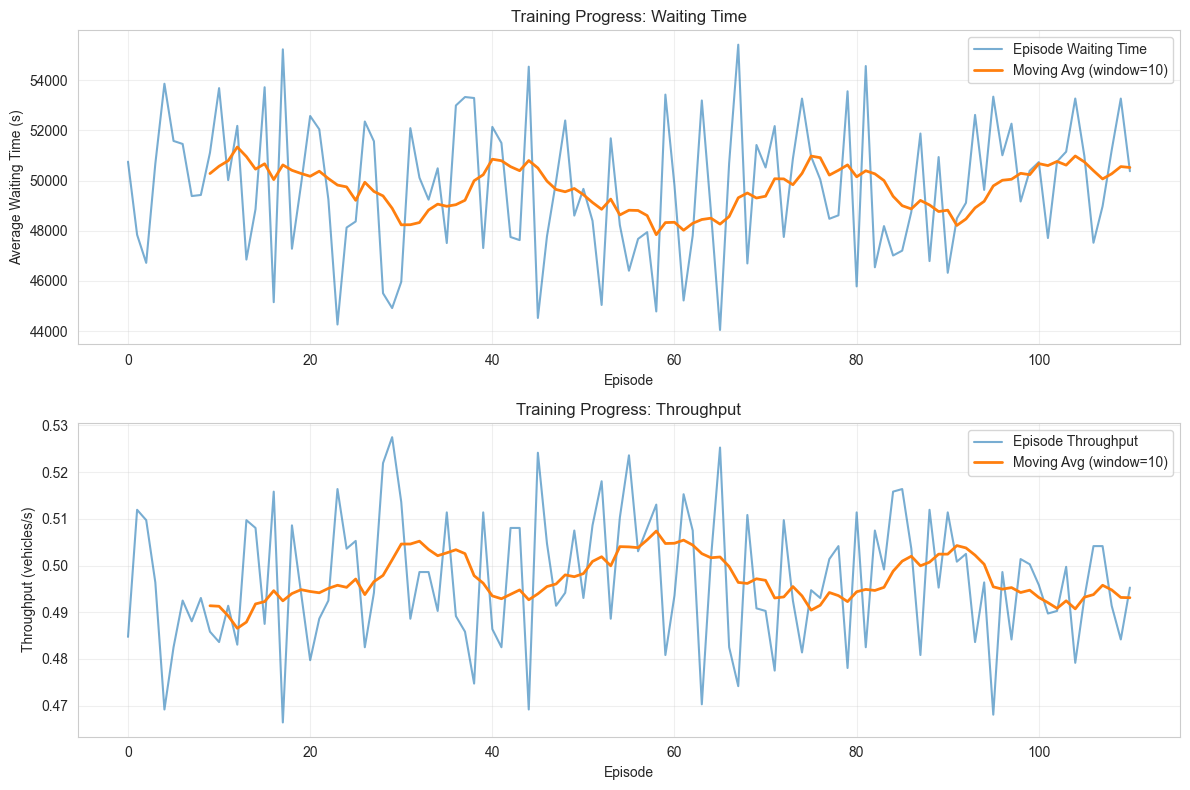

✓ Training plots generated


In [16]:
# Plot training metrics
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot waiting times
axes[0].plot(metrics_callback.waiting_times, alpha=0.6, label='Episode Waiting Time')
# Smooth with moving average
window = 10
if len(metrics_callback.waiting_times) > window:
    smoothed = pd.Series(metrics_callback.waiting_times).rolling(window).mean()
    axes[0].plot(smoothed, linewidth=2, label=f'Moving Avg (window={window})')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Average Waiting Time (s)')
axes[0].set_title('Training Progress: Waiting Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot throughput
axes[1].plot(metrics_callback.throughputs, alpha=0.6, label='Episode Throughput')
if len(metrics_callback.throughputs) > window:
    smoothed = pd.Series(metrics_callback.throughputs).rolling(window).mean()
    axes[1].plot(smoothed, linewidth=2, label=f'Moving Avg (window={window})')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Throughput (vehicles/s)')
axes[1].set_title('Training Progress: Throughput')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training plots generated")

## 6. Evaluation <a name="evaluation"></a>

### 6.1 Evaluate Trained Agent

In [17]:
# Load the best model (if you want to use the best from eval callback)
# agent = PPO.load("./models/best_model")

def evaluate_agent(model, env, n_episodes=10, render=False):
    """Evaluate an RL agent."""
    
    metrics = {
        'avg_waiting_time': [],
        'throughput': [],
        'total_passed': [],
        'episode_rewards': []
    }
    
    for episode in range(n_episodes):
        obs, _ = env.reset()
        done = False
        episode_reward = 0
        
        while not done:
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            done = terminated or truncated
            
            if render:
                env.render()
        
        metrics['avg_waiting_time'].append(info['avg_waiting_time'])
        metrics['throughput'].append(info['throughput'])
        metrics['total_passed'].append(info['vehicles_passed'])
        metrics['episode_rewards'].append(episode_reward)
    
    return {
        'controller': 'RL Agent (PPO)',
        'avg_waiting_time': np.mean(metrics['avg_waiting_time']),
        'avg_throughput': np.mean(metrics['throughput']),
        'avg_vehicles_passed': np.mean(metrics['total_passed']),
        'std_waiting_time': np.std(metrics['avg_waiting_time']),
        'avg_episode_reward': np.mean(metrics['episode_rewards'])
    }

# Evaluate the trained agent
print("Evaluating trained RL agent...\n")
rl_results = evaluate_agent(agent, eval_env, n_episodes=10)

print("RL Agent Results:")
print(f"  Avg Waiting Time: {rl_results['avg_waiting_time']:.2f}s")
print(f"  Avg Throughput: {rl_results['avg_throughput']:.4f} vehicles/s")
print(f"  Avg Vehicles Passed: {rl_results['avg_vehicles_passed']:.0f}")
print(f"  Avg Episode Reward: {rl_results['avg_episode_reward']:.2f}")

Evaluating trained RL agent...

RL Agent Results:
  Avg Waiting Time: 50762.91s
  Avg Throughput: 0.4929 vehicles/s
  Avg Vehicles Passed: 888
  Avg Episode Reward: -580055.60


### 6.2 Compare with Baselines


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
FINAL COMPARISON: RL Agent vs Baselines
    controller  avg_waiting_time  avg_throughput  avg_vehicles_passed  std_waiting_time  avg_episode_reward
    Fixed-Time      4.901900e+04        0.490616                883.6       3057.763052                 NaN
      Actuated      6.916533e+04        0.422876                761.6      12616.572554                 NaN
  Max-Pressure      1.139466e+06        0.027207                 49.0     225611.521850                 NaN
RL Agent (PPO)      5.076291e+04        0.492893                887.7       3074.529423         -580055.598




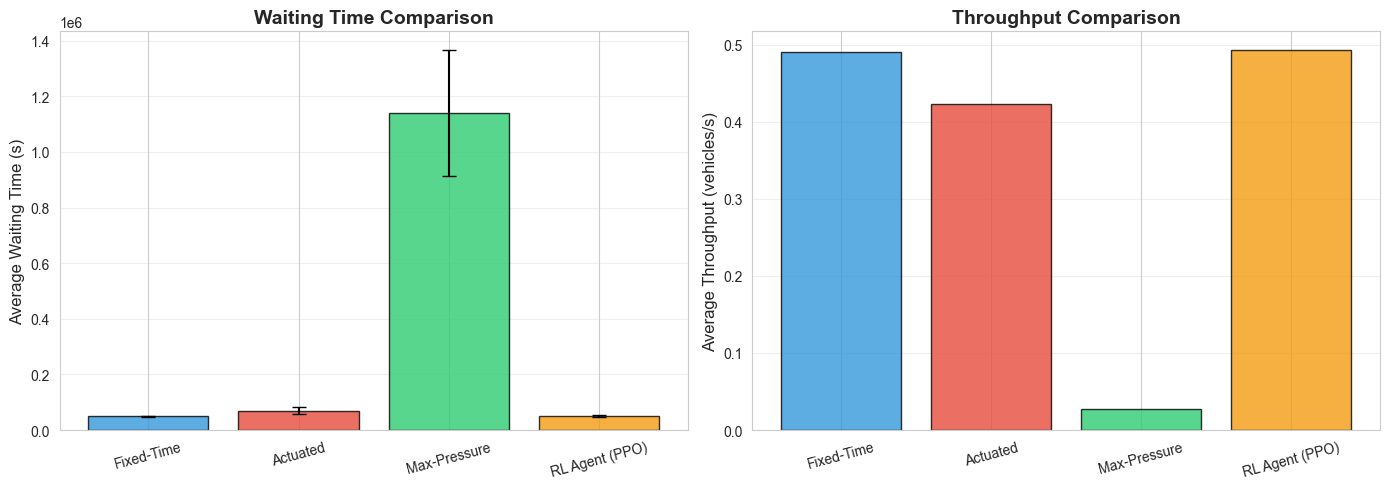

✓ Comparison complete!


In [18]:
# Combine all results
all_results = baseline_results + [rl_results]
comparison_df = pd.DataFrame(all_results)

print("\n=" * 80)
print("FINAL COMPARISON: RL Agent vs Baselines")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("\n")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Waiting time comparison
controllers = comparison_df['controller'].values
waiting_times = comparison_df['avg_waiting_time'].values
std_waiting = comparison_df['std_waiting_time'].values

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars1 = axes[0].bar(controllers, waiting_times, yerr=std_waiting, 
                     capsize=5, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Average Waiting Time (s)', fontsize=12)
axes[0].set_title('Waiting Time Comparison', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')

# Throughput comparison
throughputs = comparison_df['avg_throughput'].values
bars2 = axes[1].bar(controllers, throughputs, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Average Throughput (vehicles/s)', fontsize=12)
axes[1].set_title('Throughput Comparison', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Comparison complete!")

## 7. Results and Analysis <a name="results"></a>

### 7.1 Visualize Agent Behavior

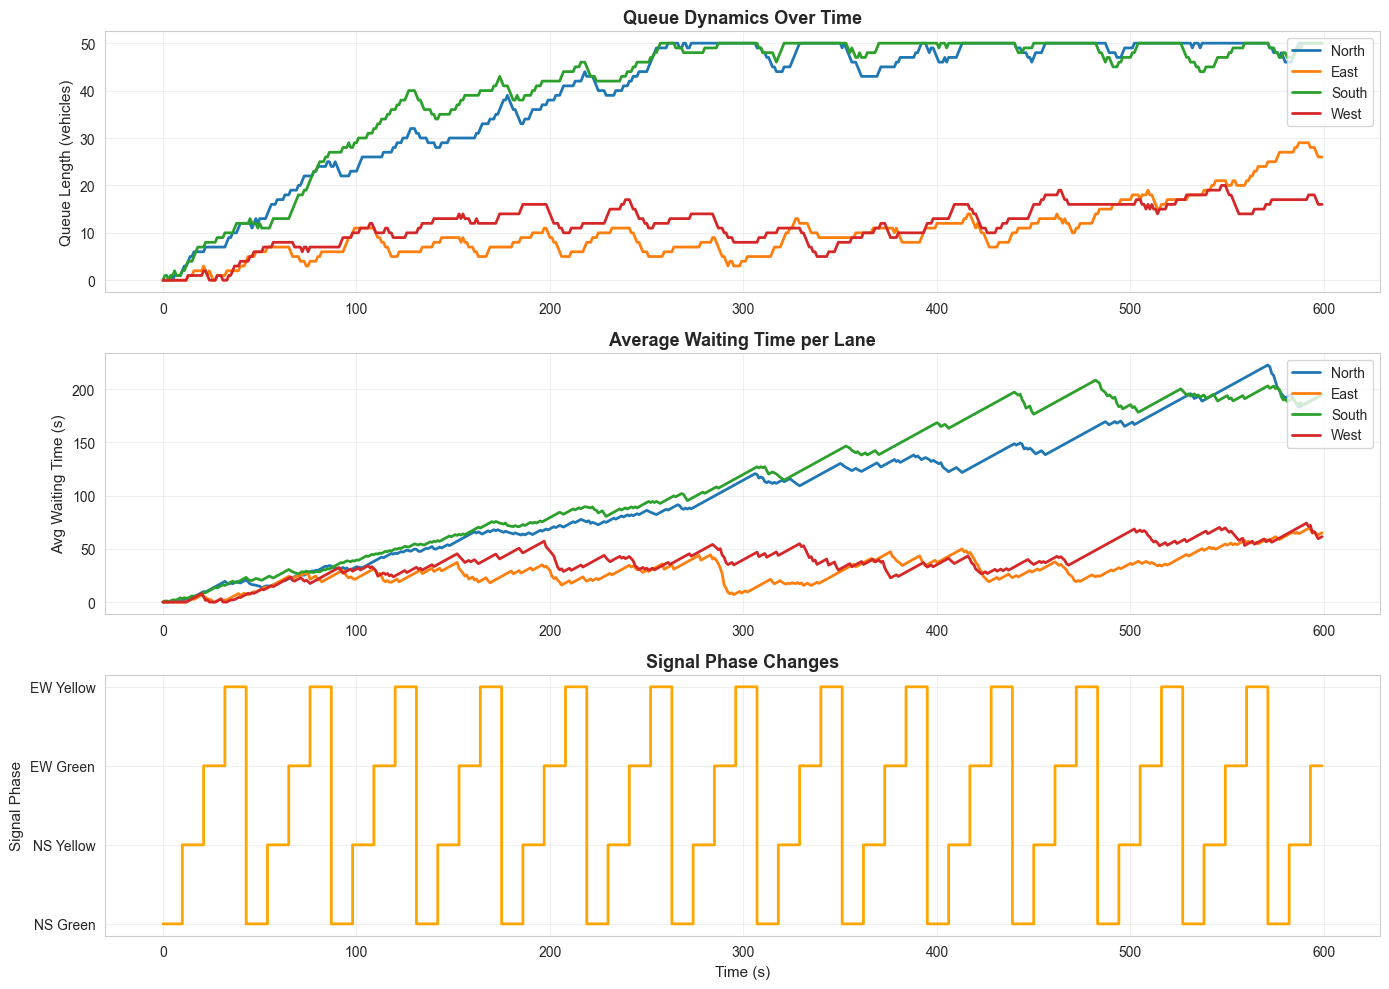

✓ Agent behavior visualization complete


In [19]:
# Run one episode and visualize behavior
vis_env = TrafficSignalEnv(
    arrival_rates=[0.3, 0.2, 0.3, 0.2],  # Asymmetric traffic
    episode_length=600,  # 10 minutes
    dt=1.0
)

obs, _ = vis_env.reset()
done = False

while not done:
    action, _ = agent.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = vis_env.step(action)
    done = terminated or truncated

# Extract history
history = vis_env.history
time_steps = np.arange(len(history['queue_lengths']))

# Plot queue dynamics
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Queue lengths over time
queue_data = np.array(history['queue_lengths'])
labels = ['North', 'East', 'South', 'West']
for i in range(4):
    axes[0].plot(time_steps, queue_data[:, i], label=labels[i], linewidth=2)
axes[0].set_ylabel('Queue Length (vehicles)', fontsize=11)
axes[0].set_title('Queue Dynamics Over Time', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Waiting times
waiting_data = np.array(history['waiting_times'])
for i in range(4):
    axes[1].plot(time_steps, waiting_data[:, i], label=labels[i], linewidth=2)
axes[1].set_ylabel('Avg Waiting Time (s)', fontsize=11)
axes[1].set_title('Average Waiting Time per Lane', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Signal phases
phases = np.array(history['phases'])
axes[2].step(time_steps, phases, where='post', linewidth=2, color='orange')
axes[2].set_xlabel('Time (s)', fontsize=11)
axes[2].set_ylabel('Signal Phase', fontsize=11)
axes[2].set_title('Signal Phase Changes', fontsize=13, fontweight='bold')
axes[2].set_yticks([0, 1, 2, 3])
axes[2].set_yticklabels(['NS Green', 'NS Yellow', 'EW Green', 'EW Yellow'])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('agent_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Agent behavior visualization complete")

### 7.2 Test Different Traffic Scenarios

Testing agent on different traffic scenarios...

Balanced Traffic:
  Waiting Time: 50354.89s
  Throughput: 0.4966 vehicles/s

Heavy North-South:
  Waiting Time: 39571.76s
  Throughput: 0.4880 vehicles/s

Heavy East-West:
  Waiting Time: 38752.32s
  Throughput: 0.4927 vehicles/s

Asymmetric:
  Waiting Time: 49697.39s
  Throughput: 0.5052 vehicles/s



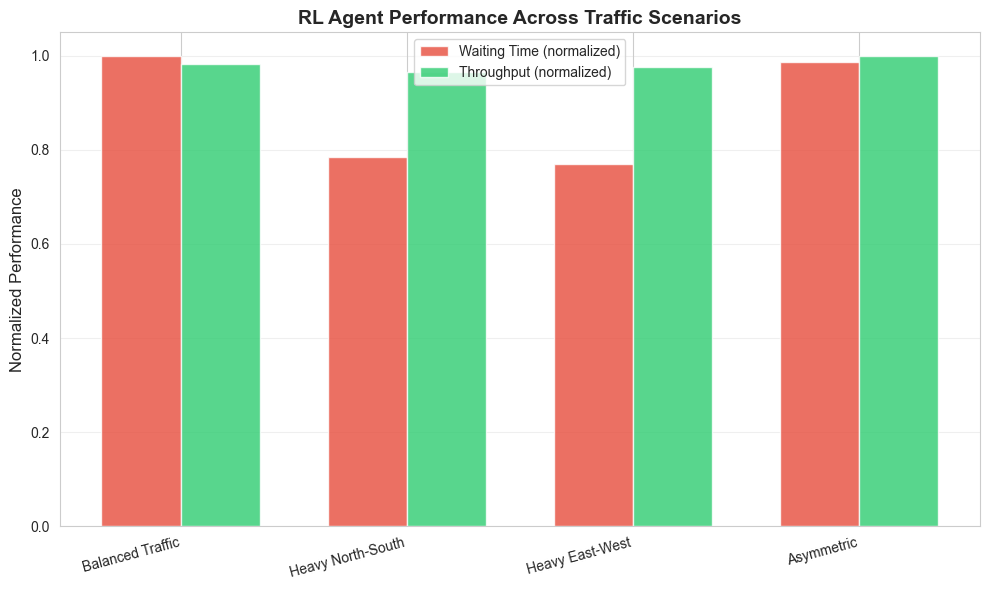

✓ Scenario testing complete


In [20]:
# Test on different traffic patterns
scenarios = [
    {
        'name': 'Balanced Traffic',
        'rates': [0.25, 0.25, 0.25, 0.25]
    },
    {
        'name': 'Heavy North-South',
        'rates': [0.4, 0.15, 0.4, 0.15]
    },
    {
        'name': 'Heavy East-West',
        'rates': [0.15, 0.4, 0.15, 0.4]
    },
    {
        'name': 'Asymmetric',
        'rates': [0.35, 0.2, 0.25, 0.3]
    }
]

scenario_results = []

print("Testing agent on different traffic scenarios...\n")

for scenario in scenarios:
    test_env = TrafficSignalEnv(
        arrival_rates=scenario['rates'],
        episode_length=1800
    )
    
    results = evaluate_agent(agent, test_env, n_episodes=5)
    results['scenario'] = scenario['name']
    scenario_results.append(results)
    
    print(f"{scenario['name']}:")
    print(f"  Waiting Time: {results['avg_waiting_time']:.2f}s")
    print(f"  Throughput: {results['avg_throughput']:.4f} vehicles/s\n")

# Visualize scenario performance
scenario_df = pd.DataFrame(scenario_results)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(scenarios))
width = 0.35

# Normalize metrics for better visualization
normalized_waiting = scenario_df['avg_waiting_time'] / scenario_df['avg_waiting_time'].max()
normalized_throughput = scenario_df['avg_throughput'] / scenario_df['avg_throughput'].max()

bars1 = ax.bar(x - width/2, normalized_waiting, width, 
               label='Waiting Time (normalized)', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, normalized_throughput, width,
               label='Throughput (normalized)', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Normalized Performance', fontsize=12)
ax.set_title('RL Agent Performance Across Traffic Scenarios', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([s['name'] for s in scenarios], rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('scenario_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Scenario testing complete")

### 7.3 Summary and Conclusions

In [21]:
print("="*80)
print("TRAFFIC SIGNAL OPTIMIZATION - SUMMARY")
print("="*80)

print("\n1. BASELINE COMPARISON")
print("-" * 80)
print(comparison_df.to_string(index=False))

# Calculate improvements
best_baseline_waiting = comparison_df[comparison_df['controller'] != 'RL Agent (PPO)']['avg_waiting_time'].min()
rl_waiting = rl_results['avg_waiting_time']
improvement_waiting = ((best_baseline_waiting - rl_waiting) / best_baseline_waiting) * 100

best_baseline_throughput = comparison_df[comparison_df['controller'] != 'RL Agent (PPO)']['avg_throughput'].max()
rl_throughput = rl_results['avg_throughput']
improvement_throughput = ((rl_throughput - best_baseline_throughput) / best_baseline_throughput) * 100

print("\n2. KEY FINDINGS")
print("-" * 80)
print(f"• RL Agent vs Best Baseline:")
print(f"  - Waiting Time Improvement: {improvement_waiting:+.2f}%")
print(f"  - Throughput Improvement: {improvement_throughput:+.2f}%")

print("\n3. SCENARIO ROBUSTNESS")
print("-" * 80)
print(scenario_df[['scenario', 'avg_waiting_time', 'avg_throughput']].to_string(index=False))

print("\n4. NEXT STEPS")
print("-" * 80)
print("• Experiment with different reward functions")
print("• Test with variable episode lengths")
print("• Add pedestrian crossing logic")
print("• Scale to multi-intersection networks")
print("• Integrate with SUMO for realistic simulation")
print("• Implement transfer learning for different intersections")
print("• Add real-time adaptability with online learning")

print("\n" + "="*80)
print("Project Complete! All visualizations saved to disk.")
print("="*80)

TRAFFIC SIGNAL OPTIMIZATION - SUMMARY

1. BASELINE COMPARISON
--------------------------------------------------------------------------------
    controller  avg_waiting_time  avg_throughput  avg_vehicles_passed  std_waiting_time  avg_episode_reward
    Fixed-Time      4.901900e+04        0.490616                883.6       3057.763052                 NaN
      Actuated      6.916533e+04        0.422876                761.6      12616.572554                 NaN
  Max-Pressure      1.139466e+06        0.027207                 49.0     225611.521850                 NaN
RL Agent (PPO)      5.076291e+04        0.492893                887.7       3074.529423         -580055.598

2. KEY FINDINGS
--------------------------------------------------------------------------------
• RL Agent vs Best Baseline:
  - Waiting Time Improvement: -3.56%
  - Throughput Improvement: +0.46%

3. SCENARIO ROBUSTNESS
--------------------------------------------------------------------------------
         scen

## 8. Save and Export <a name="export"></a>

In [22]:
# Save all results to CSV
comparison_df.to_csv('baseline_comparison.csv', index=False)
scenario_df.to_csv('scenario_results.csv', index=False)

# Save model
agent.save('traffic_signal_rl_final')

print("✓ All results saved!")
print("\nFiles created:")
print("  - traffic_signal_rl_final.zip (trained model)")
print("  - baseline_comparison.csv")
print("  - scenario_results.csv")
print("  - training_progress.png")
print("  - baseline_comparison.png")
print("  - agent_behavior.png")
print("  - scenario_performance.png")
print("  - qlearning_training_progress.png")
print("  - full_comparison.png")
print("  - ql_vs_ppo_scenarios.png")

✓ All results saved!

Files created:
  - traffic_signal_rl_final.zip (trained model)
  - baseline_comparison.csv
  - scenario_results.csv
  - training_progress.png
  - baseline_comparison.png
  - agent_behavior.png
  - scenario_performance.png


---

## Appendix: Hyperparameter Tuning (Optional)

Use this section to experiment with different hyperparameters.

In [ ]:
# Hyperparameter search space (example)
hyperparams_to_test = [
    {'learning_rate': 1e-3, 'ent_coef': 0.01, 'name': 'High LR'},
    {'learning_rate': 3e-4, 'ent_coef': 0.01, 'name': 'Medium LR'},
    {'learning_rate': 1e-4, 'ent_coef': 0.01, 'name': 'Low LR'},
]

# Uncomment to run hyperparameter search
# for params in hyperparams_to_test:
#     print(f"\nTesting: {params['name']}")
#     test_agent = PPO(
#         "MlpPolicy",
#         train_env,
#         learning_rate=params['learning_rate'],
#         ent_coef=params['ent_coef'],
#         verbose=0
#     )
#     test_agent.learn(total_timesteps=50000)
#     results = evaluate_agent(test_agent, eval_env, n_episodes=5)
#     print(f"Results: {results}")